In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error

In [3]:
ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

df = pd.merge(ratings, movies, on='movieId')

df.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [4]:
user_item_matrix = df.pivot_table(
    index='userId',
    columns='title',
    values='rating',
    aggfunc='mean'
).fillna(0)

In [5]:
matrix = user_item_matrix.values

In [6]:
k = 20 

model = NMF(n_components=k, init='random', random_state=42, max_iter=200)

W = model.fit_transform(matrix)   
H = model.components_             

c:\Users\JANANI.K\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


In [7]:
reconstructed = np.dot(W, H)

reconstructed_df = pd.DataFrame(
    reconstructed,
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
)
dff=pd.DataFrame(user_item_matrix)
dff.info()

<class 'pandas.core.frame.DataFrame'>
Index: 610 entries, 1 to 610
Columns: 9719 entries, '71 (2014) to À nous la liberté (Freedom for Us) (1931)
dtypes: float64(9719)
memory usage: 45.2 MB


In [8]:
predicted_ratings = reconstructed_df
predicted_ratings.head()

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,0.000000,0.012214,0.011175,0.008585,0.000546,0.000000,0.800537,0.0,0.152084,0.061276,...,0.0,0.090010,0.001948,0.000000,0.000000,0.181564,0.073031,0.042799,0.954578,0.020809
2,0.000000,0.007251,0.006030,0.000104,0.000070,0.004493,0.000909,0.0,0.137381,0.000000,...,0.0,0.007939,0.002725,0.000000,0.002969,0.015581,0.026754,0.002568,0.014130,0.000000
3,0.006312,0.000000,0.000000,0.000436,0.000000,0.000016,0.039803,0.0,0.005478,0.000045,...,0.0,0.010719,0.008027,0.007256,0.000000,0.003367,0.005553,0.002315,0.046331,0.001057
4,0.000000,0.013497,0.013934,0.009745,0.043049,0.000000,0.015579,0.0,0.176373,0.029522,...,0.0,0.004822,0.000000,0.000000,0.000000,0.365820,0.004467,0.000000,0.072571,0.001004
5,0.000000,0.001598,0.001483,0.000526,0.002376,0.000000,0.000000,0.0,0.042347,0.002777,...,0.0,0.002404,0.000498,0.000000,0.000000,0.015051,0.000000,0.000000,0.004934,0.000198


In [9]:
def recommend_movies_nmf(user_id, n=10):
    user_row = reconstructed_df.loc[user_id]
    already_rated = user_item_matrix.loc[user_id]

    recommendations = user_row[already_rated == 0]
    recommendations = recommendations.sort_values(ascending=False)

    return recommendations.head(n)

recommend_movies_nmf(1)

title
Aliens (1986)                             4.242207
Terminator 2: Judgment Day (1991)         4.179159
Star Trek II: The Wrath of Khan (1982)    3.264011
Die Hard (1988)                           3.251964
Sixth Sense, The (1999)                   3.135938
Blade Runner (1982)                       3.025754
Stand by Me (1986)                        3.013147
Star Trek: First Contact (1996)           2.991843
Hunt for Red October, The (1990)          2.967426
Godfather, The (1972)                     2.915382
Name: 1, dtype: float64

In [10]:
actual = user_item_matrix.values.flatten()
predicted = reconstructed_df.values.flatten()

rmse = np.sqrt(mean_squared_error(actual, predicted))

print("RMSE:", rmse)

RMSE: 0.35978834640494917


In [11]:
mask = user_item_matrix.values != 0

actual = user_item_matrix.values[mask]
predicted = reconstructed_df.values[mask]

rmse = np.sqrt(mean_squared_error(actual, predicted))
print("Correct NMF RMSE:", rmse)

Correct NMF RMSE: 2.4653908914639038


In [12]:
def precision_recall_at_k(user_id, k=10, threshold=3.5):
    actual_ratings = user_item_matrix.loc[user_id]
    predicted_ratings = reconstructed_df.loc[user_id]

    relevant = actual_ratings[actual_ratings >= threshold].index

    recommended = predicted_ratings.sort_values(ascending=False).head(k).index

    relevant_and_recommended = set(relevant).intersection(set(recommended))

    precision = len(relevant_and_recommended) / k
    recall = len(relevant_and_recommended) / len(relevant) if len(relevant) > 0 else 0

    return precision, recall

p, r = precision_recall_at_k(1, k=10)

print("Precision@10:", p)
print("Recall@10:", r)

Precision@10: 0.8
Recall@10: 0.04


In [13]:
print("NMF RMSE:", rmse)

NMF RMSE: 2.4653908914639038


In [14]:
print("User-feature matrix (W):")
print(W[:5])

print("Item-feature matrix (H):")
print(H[:, :5])

User-feature matrix (W):
[[0.         0.         0.         0.13725147 0.         0.
  0.04063449 0.03158046 0.00532304 0.         0.         0.03174213
  0.         0.         0.         0.03434032 0.07222269 1.00982059
  0.         0.        ]
 [0.         0.         0.15013434 0.         0.         0.
  0.         0.         0.         0.         0.         0.05428331
  0.         0.         0.03169717 0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.05316323
  0.00304687 0.0173528 ]
 [0.         0.         0.         0.13661259 0.89687122 0.
  0.         0.04350067 0.00327899 0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.04840099 0.
  0.         0.00858997 0.         0.         0.         0.0099

In [15]:
sparsity = np.mean(matrix == 0)
print("Sparsity of dataset:", sparsity)

Sparsity of dataset: 0.9829922460483859


In [16]:
rec1 = set(recommend_movies_nmf(1, 10).index)
rec2 = set(recommend_movies_nmf(2, 10).index)

diversity = len(rec1.symmetric_difference(rec2))
print("Diversity between users:", diversity)

Diversity between users: 18


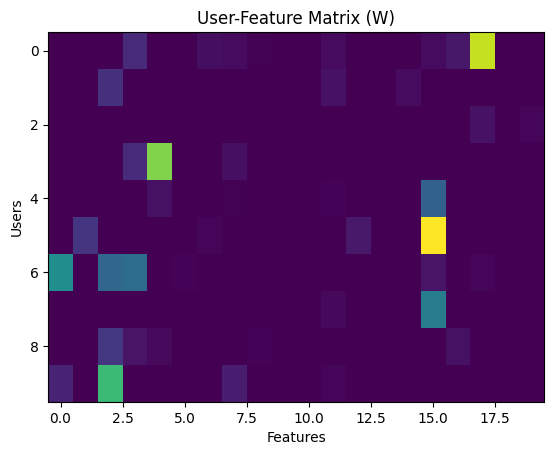

In [17]:
plt.figure()
plt.imshow(W[:10], aspect='auto')
plt.title("User-Feature Matrix (W)")
plt.xlabel("Features")
plt.ylabel("Users")
plt.show()

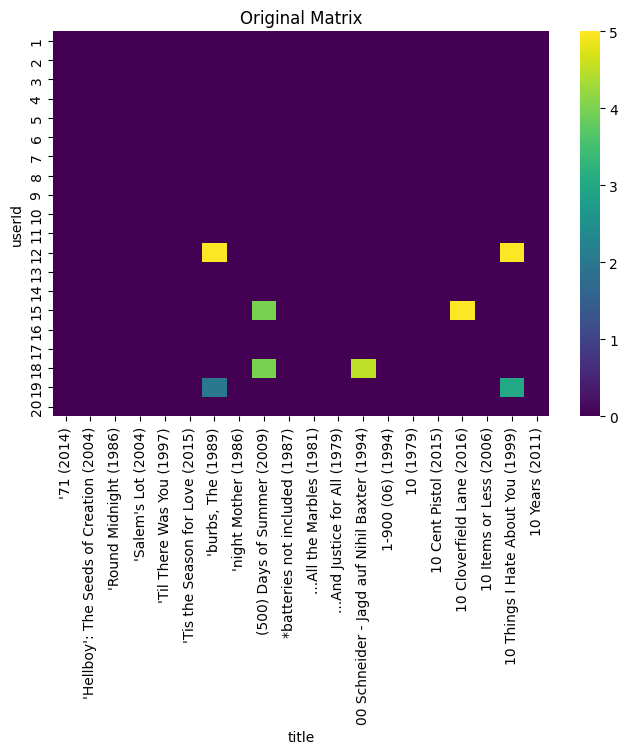

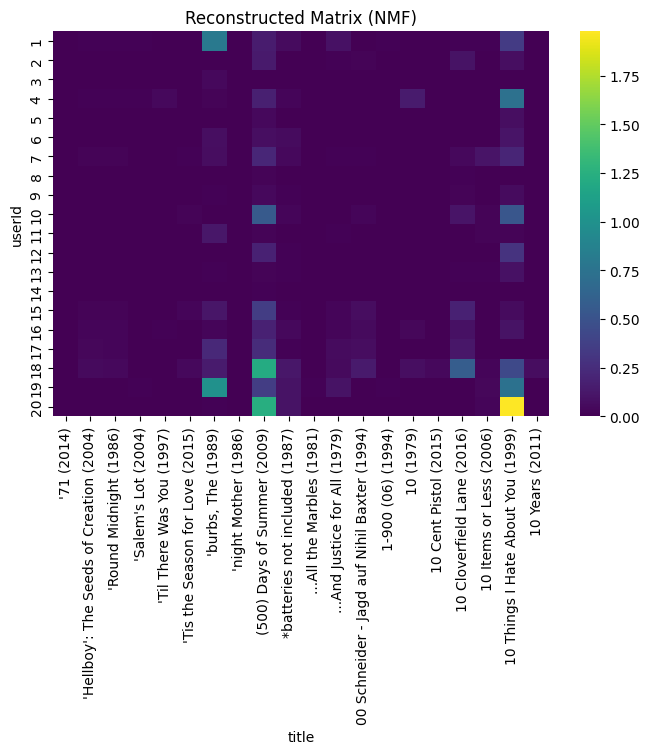

In [23]:
plt.figure(figsize=(8,5))
sns.heatmap(user_item_matrix.iloc[:20, :20], cmap='viridis')
plt.title("Original Matrix")
plt.show()

plt.figure(figsize=(8,5))
sns.heatmap(reconstructed_df.iloc[:20, :20], cmap='viridis')
plt.title("Reconstructed Matrix (NMF)")
plt.show()

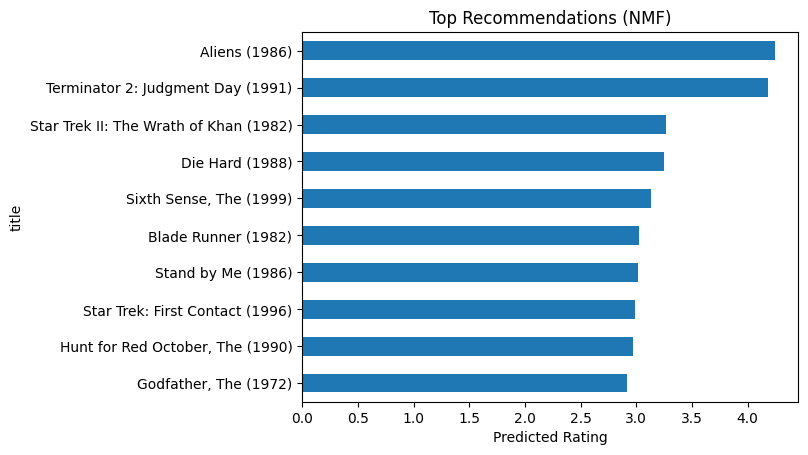

In [19]:
top_movies = recommend_movies_nmf(1, 10)

top_movies.sort_values().plot(kind='barh')
plt.title("Top Recommendations (NMF)")
plt.xlabel("Predicted Rating")
plt.show()